In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import random
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid

In [3]:
# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Define paths
base_dir = '../data/DAWN_processed'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Define classes (weather conditions)
classes = ['Fog', 'Rain', 'Snow', 'Sand']

# Define parameters
img_height, img_width = 224, 224
batch_size = 32
epochs = 20  # Increased epochs for better training
learning_rate = 0.0001
weight_decay = 1e-4  # L2 regularization

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:

# Data transformations
train_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.25), ratio=(0.3, 3.3))  # Added RandomErasing for robust training.
])

val_test_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=False)

print(f"Classes: {train_dataset.classes}")
print(f"Class to idx mapping: {train_dataset.class_to_idx}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")



Classes: ['Fog', 'Rain', 'Sand', 'Snow']
Class to idx mapping: {'Fog': 0, 'Rain': 1, 'Sand': 2, 'Snow': 3}
Training samples: 718
Validation samples: 204
Test samples: 105


In [5]:
# Define CNN model (using pre-trained ResNet18 with modifications)
def create_pretrained_model(num_classes=4):
    model = models.resnet18(weights='IMAGENET1K_V1')
    # Freeze early layers
    for param in list(model.parameters())[:-4]:
        param.requires_grad = False
    # Add dropout and batch normalization after ResNet's feature extractor
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, 512),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(512),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model


model = create_pretrained_model(num_classes=len(classes)).to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)  # Added weight decay.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3,
                                                 verbose=True)  # increased patience



F:\DevCache\conda\envs\main\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [6]:
# Training function (same as before)
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs):
    model.train()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        model.train()
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [Train]")
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            train_bar.set_postfix({'loss': loss.item(), 'acc': 100 * correct / total})

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100 * correct / total

        val_loss, val_acc = evaluate_model(model, val_loader, criterion)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()

        print(f'Epoch {epoch + 1}/{num_epochs}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"Loaded best model with validation loss: {best_val_loss:.4f}")

    return model, history



In [7]:
# Evaluation function (same as before)
def evaluate_model(model, data_loader, criterion=None):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            if criterion:
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(data_loader.dataset) if criterion else 0
    acc = 100 * correct / total

    return avg_loss, acc


# Plot function
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot accuracy
    ax1.plot(history['train_acc'])
    ax1.plot(history['val_acc'])
    ax1.set_title('Model accuracy')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')

    # Plot loss
    ax2.plot(history['train_loss'])
    ax2.plot(history['val_loss'])
    ax2.set_title('Model loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()


# Confusion matrix function
def plot_confusion_matrix(model, data_loader, classes):
    y_true = []
    y_pred = []

    model.eval()
    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc="Generating predictions"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('confusion_matrix.png')
    plt.show()

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))

    return y_true, y_pred



In [8]:
# Visualize predictions function
def visualize_predictions(model, data_loader, classes, num_images=12):
    model.eval()

    # Get a batch of images
    dataiter = iter(data_loader)
    images, labels = next(dataiter)
    images, labels = images[:num_images], labels[:num_images]

    # Make predictions
    with torch.no_grad():
        outputs = model(images.to(device))
        _, predicted = torch.max(outputs, 1)
        predicted = predicted.cpu()

    # Plot images with predictions
    fig = plt.figure(figsize=(15, 10))

    for i in range(num_images):
        # Add subplot
        ax = fig.add_subplot(3, 4, i + 1)

        # Un-normalize the image for display
        img = images[i].cpu().numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        # Display the image
        ax.imshow(img)

        # Add titles
        true_label = classes[labels[i]]
        pred_label = classes[predicted[i]]
        title_color = 'green' if labels[i] == predicted[i] else 'red'
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=title_color)
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('prediction_examples.png')
    plt.show()



In [9]:
# Function to predict a single image
def predict_image(model, image_path, classes, transform=None):
    if transform is None:
        transform = val_test_transforms

    # Load and preprocess the image
    from PIL import Image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]
        _, predicted_idx = torch.max(probabilities, 0)

    # Get the predicted class and confidence
    predicted_class = classes[predicted_idx.item()]
    confidence = probabilities[predicted_idx].item()

    # Get all class probabilities
    all_probs = {classes[i]: prob.item() for i, prob in enumerate(probabilities)}

    return {
        'class': predicted_class,
        'confidence': confidence,
        'all_probabilities': all_probs
    }


# Function to load the saved model for later use
def load_model(model_path, num_classes=4):
    checkpoint = torch.load(model_path)

    # Create a new model instance
    model = create_pretrained_model(num_classes=num_classes)

    # Load the saved state dict
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()

    return model, checkpoint['classes']




Training with Adam optimizer...



Epoch 1/20 [Train]: 100%|██████████| 23/23 [00:08<00:00,  2.68it/s, loss=1.3, acc=28.7] 


Epoch 1/20: Train Loss: 1.4507, Train Acc: 28.69%, Val Loss: 1.3278, Val Acc: 38.24%


Epoch 2/20 [Train]: 100%|██████████| 23/23 [00:05<00:00,  4.41it/s, loss=1.33, acc=36.8]


Epoch 2/20: Train Loss: 1.3573, Train Acc: 36.77%, Val Loss: 1.1865, Val Acc: 48.04%


...

Epoch 19/20 [Train]: 100%|██████████| 23/23 [00:05<00:00,  3.93it/s, loss=0.862, acc=69.1]


Epoch 19/20: Train Loss: 0.7716, Train Acc: 69.08%, Val Loss: 0.6620, Val Acc: 75.00%


Epoch 20/20 [Train]: 100%|██████████| 23/23 [00:05<00:00,  4.30it/s, loss=0.664, acc=70.6]


Epoch 20/20: Train Loss: 0.7424, Train Acc: 70.61%, Val Loss: 0.6461, Val Acc: 75.98%
Loaded best model with validation loss: 0.6461


Generating predictions: 100%|██████████| 4/4 [00:03<00:00,  1.07it/s]


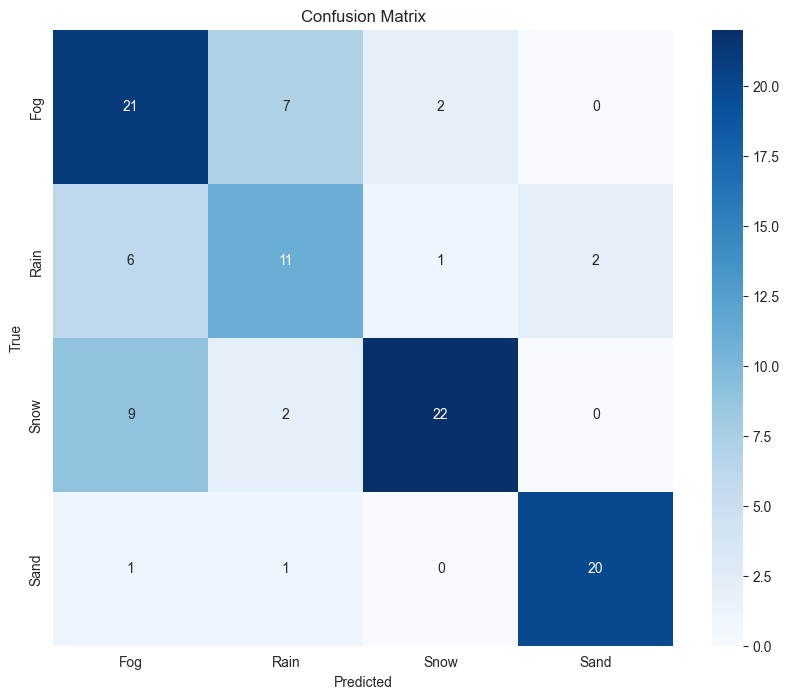

F:\DevCache\conda\envs\main\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Classification Report:
              precision    recall  f1-score   support

         Fog       0.57      0.70      0.63        30
        Rain       0.52      0.55      0.54        20
        Snow       0.88      0.67      0.76        33
        Sand       0.91      0.91      0.91        22

    accuracy                           0.70       105
   macro avg       0.72      0.71      0.71       105
weighted avg       0.73      0.70      0.71       105

Completed training with Adam. Test Loss: 0.7363, Test Accuracy: 70.48%

Training with SGD optimizer...



Epoch 1/20 [Train]: 100%|██████████| 23/23 [00:06<00:00,  3.83it/s, loss=1.41, acc=25.9]


Epoch 1/20: Train Loss: 1.5535, Train Acc: 25.91%, Val Loss: 1.4095, Val Acc: 22.06%


Epoch 2/20 [Train]: 100%|██████████| 23/23 [00:05<00:00,  4.20it/s, loss=1.41, acc=30.1]


...

Epoch 19/20 [Train]: 100%|██████████| 23/23 [00:05<00:00,  3.84it/s, loss=1.14, acc=55.4] 


Epoch 19/20: Train Loss: 1.0478, Train Acc: 55.43%, Val Loss: 0.9702, Val Acc: 63.73%


Epoch 20/20 [Train]: 100%|██████████| 23/23 [00:05<00:00,  3.85it/s, loss=1.18, acc=52.2] 


Epoch 20/20: Train Loss: 1.0872, Train Acc: 52.23%, Val Loss: 0.9595, Val Acc: 65.20%
Loaded best model with validation loss: 0.9595


Generating predictions: 100%|██████████| 4/4 [00:04<00:00,  1.06s/it]


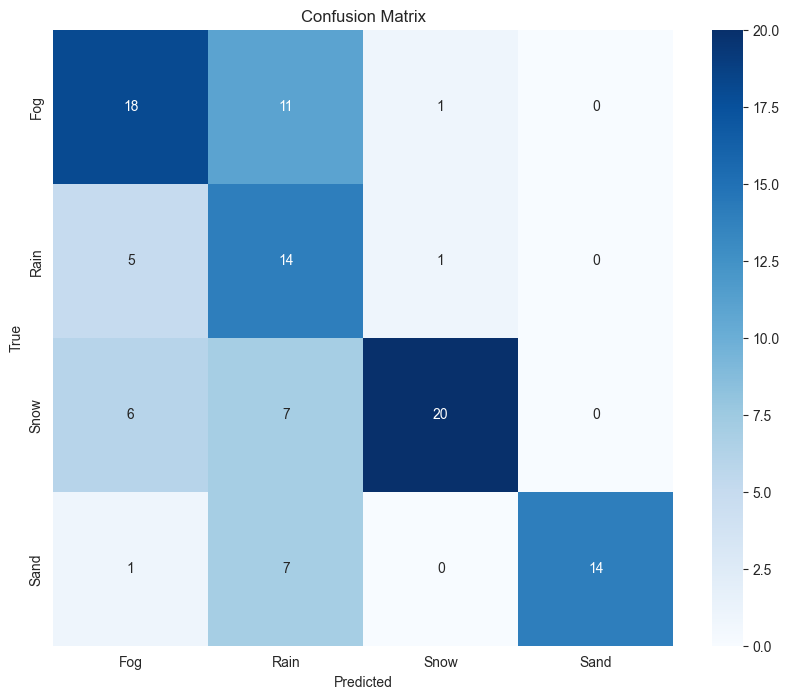

F:\DevCache\conda\envs\main\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Classification Report:
              precision    recall  f1-score   support

         Fog       0.60      0.60      0.60        30
        Rain       0.36      0.70      0.47        20
        Snow       0.91      0.61      0.73        33
        Sand       1.00      0.64      0.78        22

    accuracy                           0.63       105
   macro avg       0.72      0.64      0.64       105
weighted avg       0.74      0.63      0.65       105

Completed training with SGD. Test Loss: 0.9787, Test Accuracy: 62.86%

Training with RMSprop optimizer...



Epoch 1/20 [Train]: 100%|██████████| 23/23 [00:07<00:00,  3.23it/s, loss=1.63, acc=33.4]


Epoch 1/20: Train Loss: 1.4413, Train Acc: 33.43%, Val Loss: 1.2544, Val Acc: 45.59%


Epoch 2/20 [Train]: 100%|██████████| 23/23 [00:06<00:00,  3.57it/s, loss=1.23, acc=43.3]


...

Epoch 19/20 [Train]: 100%|██████████| 23/23 [00:05<00:00,  4.00it/s, loss=0.693, acc=69.4]


Epoch 19/20: Train Loss: 0.7551, Train Acc: 69.36%, Val Loss: 0.6222, Val Acc: 76.47%


Epoch 20/20 [Train]: 100%|██████████| 23/23 [00:06<00:00,  3.71it/s, loss=0.896, acc=72.8]


Epoch 20/20: Train Loss: 0.7066, Train Acc: 72.84%, Val Loss: 0.6079, Val Acc: 77.45%
Loaded best model with validation loss: 0.6079


Generating predictions: 100%|██████████| 4/4 [00:04<00:00,  1.05s/it]


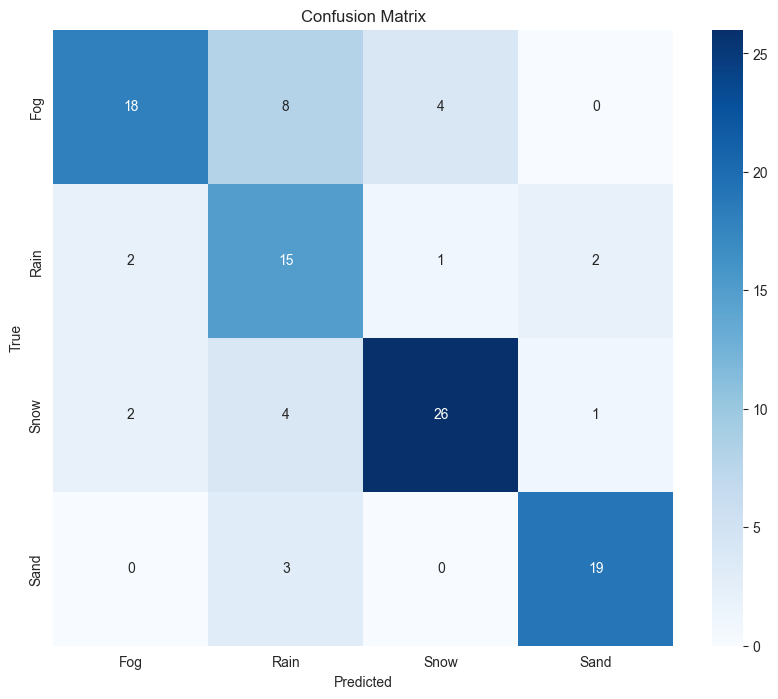

F:\DevCache\conda\envs\main\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Classification Report:
              precision    recall  f1-score   support

         Fog       0.82      0.60      0.69        30
        Rain       0.50      0.75      0.60        20
        Snow       0.84      0.79      0.81        33
        Sand       0.86      0.86      0.86        22

    accuracy                           0.74       105
   macro avg       0.76      0.75      0.74       105
weighted avg       0.77      0.74      0.75       105

Completed training with RMSprop. Test Loss: 0.7219, Test Accuracy: 74.29%

Training with Adagrad optimizer...



Epoch 1/20 [Train]: 100%|██████████| 23/23 [00:05<00:00,  4.05it/s, loss=1.32, acc=28]  


Epoch 1/20: Train Loss: 1.5291, Train Acc: 27.99%, Val Loss: 1.3230, Val Acc: 38.73%


Epoch 2/20 [Train]: 100%|██████████| 23/23 [00:06<00:00,  3.79it/s, loss=1.58, acc=29.2]


...

Epoch 19/20 [Train]: 100%|██████████| 23/23 [00:06<00:00,  3.73it/s, loss=1.23, acc=42.8]


Epoch 19/20: Train Loss: 1.2821, Train Acc: 42.76%, Val Loss: 1.1282, Val Acc: 60.78%


Epoch 20/20 [Train]: 100%|██████████| 23/23 [00:05<00:00,  4.02it/s, loss=1.45, acc=41.6]


Epoch 20/20: Train Loss: 1.2941, Train Acc: 41.64%, Val Loss: 1.1232, Val Acc: 59.80%
Loaded best model with validation loss: 1.1232


Generating predictions: 100%|██████████| 4/4 [00:03<00:00,  1.08it/s]


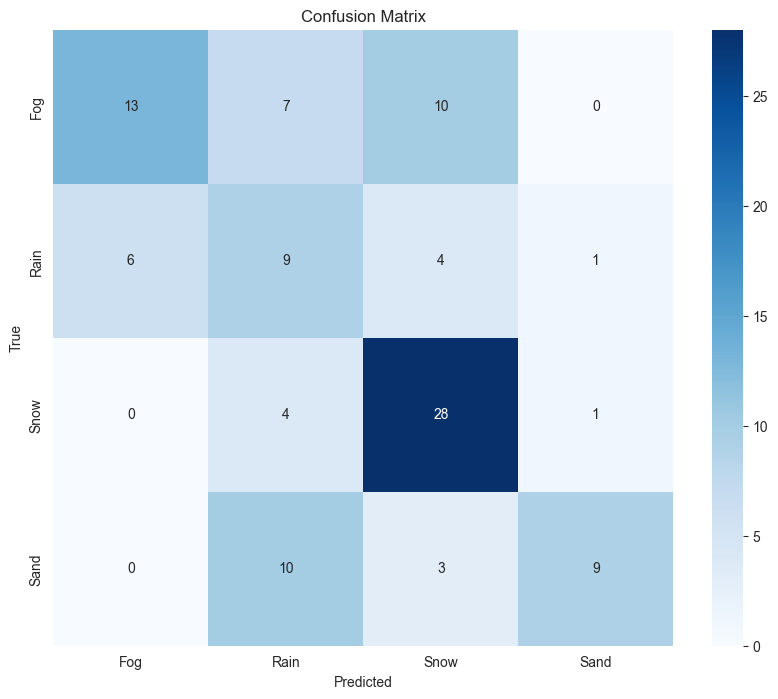

F:\DevCache\conda\envs\main\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Classification Report:
              precision    recall  f1-score   support

         Fog       0.68      0.43      0.53        30
        Rain       0.30      0.45      0.36        20
        Snow       0.62      0.85      0.72        33
        Sand       0.82      0.41      0.55        22

    accuracy                           0.56       105
   macro avg       0.61      0.54      0.54       105
weighted avg       0.62      0.56      0.56       105

Completed training with Adagrad. Test Loss: 1.1645, Test Accuracy: 56.19%

Training with AdamW optimizer...



Epoch 1/20 [Train]: 100%|██████████| 23/23 [00:05<00:00,  3.89it/s, loss=1.11, acc=28.7]


Epoch 1/20: Train Loss: 1.4603, Train Acc: 28.69%, Val Loss: 1.2428, Val Acc: 48.04%


Epoch 2/20 [Train]: 100%|██████████| 23/23 [00:05<00:00,  4.09it/s, loss=1.34, acc=42.9]


...

Epoch 19/20 [Train]: 100%|██████████| 23/23 [00:05<00:00,  3.87it/s, loss=1.25, acc=71.6] 


Epoch 19/20: Train Loss: 0.7390, Train Acc: 71.59%, Val Loss: 0.5946, Val Acc: 77.45%


Epoch 20/20 [Train]: 100%|██████████| 23/23 [00:06<00:00,  3.83it/s, loss=0.598, acc=73.1]


Epoch 20/20: Train Loss: 0.6735, Train Acc: 73.12%, Val Loss: 0.5872, Val Acc: 76.47%
Loaded best model with validation loss: 0.5872


Generating predictions: 100%|██████████| 4/4 [00:03<00:00,  1.01it/s]


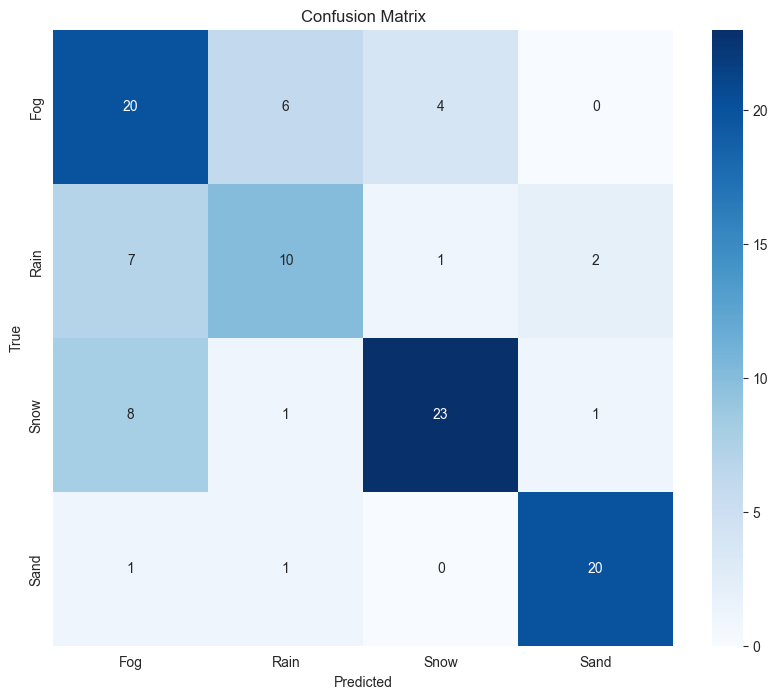


Classification Report:
              precision    recall  f1-score   support

         Fog       0.56      0.67      0.61        30
        Rain       0.56      0.50      0.53        20
        Snow       0.82      0.70      0.75        33
        Sand       0.87      0.91      0.89        22

    accuracy                           0.70       105
   macro avg       0.70      0.69      0.69       105
weighted avg       0.70      0.70      0.70       105

Completed training with AdamW. Test Loss: 0.7283, Test Accuracy: 69.52%

Optimizer: Adam
Test Loss: 0.7363, Test Accuracy: 70.48%
Precision, Recall, and F1-score:
{'Fog': {'precision': 0.5675675675675675, 'recall': 0.7, 'f1-score': 0.6268656716417911, 'support': 30.0}, 'Rain': {'precision': 0.5238095238095238, 'recall': 0.55, 'f1-score': 0.5365853658536586, 'support': 20.0}, 'Snow': {'precision': 0.88, 'recall': 0.6666666666666666, 'f1-score': 0.7586206896551724, 'support': 33.0}, 'Sand': {'precision': 0.9090909090909091, 'recall': 0.9

In [10]:
# Main execution
if __name__ == "__main__":
    # Define multiple optimizers for experimentation
    optimizers = {
        "Adam": lambda params: optim.Adam(params, lr=learning_rate, weight_decay=weight_decay),
        "SGD": lambda params: optim.SGD(params, lr=learning_rate, momentum=0.9, weight_decay=weight_decay),
        "RMSprop": lambda params: optim.RMSprop(params, lr=learning_rate, alpha=0.9, weight_decay=weight_decay),
        "Adagrad": lambda params: optim.Adagrad(params, lr=learning_rate, weight_decay=weight_decay),
        "AdamW": lambda params: optim.AdamW(params, lr=learning_rate, weight_decay=weight_decay),
    }

    results = {}

    for opt_name, opt_func in optimizers.items():
        print(f"\nTraining with {opt_name} optimizer...\n")

        # Create a fresh model instance
        model = create_pretrained_model(num_classes=len(classes)).to(device)

        # Define optimizer and scheduler
        optimizer = opt_func(model.parameters())
        criterion = nn.CrossEntropyLoss()
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

        # Train model
        trained_model, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs)

        # Evaluate model on test data
        test_loss, test_acc = evaluate_model(trained_model, test_loader, criterion)

        # Generate confusion matrix and classification report
        y_true, y_pred = plot_confusion_matrix(trained_model, test_loader, classes)
        report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)

        # Store results
        results[opt_name] = {
            "train_history": history,
            "test_loss": test_loss,
            "test_accuracy": test_acc,
            "classification_report": report
        }

        print(f"Completed training with {opt_name}. Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

    # Print summary of all optimizer results
    for opt_name, res in results.items():
        print(f"\nOptimizer: {opt_name}")
        print(f"Test Loss: {res['test_loss']:.4f}, Test Accuracy: {res['test_accuracy']:.2f}%")
        print(f"Precision, Recall, and F1-score:\n{res['classification_report']}\n")


Optimizer: Adam
Test Loss: 0.7363, Test Accuracy: 70.48%
Precision, Recall, and F1-score:
{'Fog': {'precision': 0.5675675675675675, 'recall': 0.7, 'f1-score': 0.6268656716417911, 'support': 30.0}, 'Rain': {'precision': 0.5238095238095238, 'recall': 0.55, 'f1-score': 0.5365853658536586, 'support': 20.0}, 'Snow': {'precision': 0.88, 'recall': 0.6666666666666666, 'f1-score': 0.7586206896551724, 'support': 33.0}, 'Sand': {'precision': 0.9090909090909091, 'recall': 0.9090909090909091, 'f1-score': 0.9090909090909091, 'support': 22.0}, 'accuracy': 0.7047619047619048, 'macro avg': {'precision': 0.7201170001170001, 'recall': 0.7064393939393939, 'f1-score': 0.7077906590603827, 'support': 105.0}, 'weighted avg': {'precision': 0.7289830238401667, 'recall': 0.7047619047619048, 'f1-score': 0.7102110497614057, 'support': 105.0}}


Optimizer: SGD
Test Loss: 0.9787, Test Accuracy: 62.86%
Precision, Recall, and F1-score:
{'Fog': {'precision': 0.6, 'recall': 0.6, 'f1-score': 0.6, 'support': 30.0}, 'Rain